In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r"C:\Users\hp\OneDrive\Desktop\Capstone Project\CP1\Mobile Sales data.xlsx")

### Data Cleaning & Preprocessing

In [3]:
#preview the data
df.head()

,Transaction ID,Date,Day Name,Brand,Units Sold,Price Per Unit,Customer Name,Customer Age,City,Payment Method,Customer Ratings,Mobile Model
0,41,2021-10-21,Thursday,Apple,7,65469.66,Pooja Rao,54,Delhi,UPI,5,iPhone 11
1,70,2021-10-29,Friday,Apple,4,49253.80,Pooja Reddy,21,Delhi,Cash,5,iPhone 12
2,127,2021-11-13,Saturday,Apple,4,45059.18,Kiran Solanki,27,Delhi,Cash,5,iPhone 12
3,167,2021-11-25,Thursday,Apple,2,63196.93,Pooja Thakur,36,Delhi,Credit Card,5,iPhone 12
4,225,2021-12-12,Sunday,Apple,3,65764.45,Pankaj Shah,18,Delhi,Cash,5,iPhone 11


In [4]:
#basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3835 entries, 0 to 3834
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    3835 non-null   int64         
 1   Date              3835 non-null   datetime64[ns]
 2   Day Name          3835 non-null   object        
 3   Brand             3835 non-null   object        
 4   Units Sold        3835 non-null   int64         
 5   Price Per Unit    3835 non-null   float64       
 6   Customer Name     3835 non-null   object        
 7   Customer Age      3835 non-null   int64         
 8   City              3835 non-null   object        
 9   Payment Method    3835 non-null   object        
 10  Customer Ratings  3835 non-null   int64         
 11  Mobile Model      3835 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(6)
memory usage: 359.7+ KB


In [5]:
#basic information about dataset
df.describe()

,Transaction ID,Date,Units Sold,Price Per Unit,Customer Age,Customer Ratings
count,3835.000000,3835,3835.000000,3835.000000,3835.000000,3835.000000
mean,1918.000000,2023-04-07 13:31:25.893090048,4.993481,40114.036816,38.098305,3.693090
min,1.000000,2021-10-09 00:00:00,1.000000,10011.110000,18.000000,1.000000
25%,959.500000,2022-07-10 00:00:00,3.000000,25617.405000,27.500000,3.000000
50%,1918.000000,2023-04-07 00:00:00,5.000000,40136.490000,38.000000,4.000000
75%,2876.500000,2024-01-05 00:00:00,7.000000,54973.475000,49.000000,5.000000
max,3835.000000,2024-10-08 00:00:00,9.000000,69984.480000,59.000000,5.000000
std,1107.213469,NaN,2.581122,17310.488427,12.110622,1.325069


In [6]:
#checking the missing values
df.isnull().sum()

Transaction ID      0
Date                0
Day Name            0
Brand               0
Units Sold          0
Price Per Unit      0
Customer Name       0
Customer Age        0
City                0
Payment Method      0
Customer Ratings    0
Mobile Model        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
# Create Additional Features
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

In [10]:
# Revenue Calculation
df['Revenue'] = df['Units Sold'] * df['Price Per Unit']

### Exploratory Data Analysis

In [11]:
# Total Revenue
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 769204987.97


In [12]:
# Brand-wise Sales
brand_sales = df.groupby('Brand')['Revenue'].sum().sort_values(ascending=False)
print("\\nBrand-wise Revenue:")
print(brand_sales)

\nBrand-wise Revenue:
Brand
Apple      1.616157e+08
Samsung    1.600381e+08
OnePlus    1.537194e+08
Vivo       1.500784e+08
Xiaomi     1.437533e+08
Name: Revenue, dtype: float64


In [13]:
# City-wise Sales
city_sales = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)
print("\\nCity-wise Revenue:")
print(city_sales)

\nCity-wise Revenue:
City
Delhi         2.038835e+08
Mumbai        1.271913e+08
Ranchi        3.101877e+07
Chennai       3.075953e+07
Rajkot        2.732670e+07
Jodhpur       2.717294e+07
Bangalore     2.699495e+07
Lucknow       2.684379e+07
Madurai       2.667426e+07
Gorakhpur     2.566316e+07
Indore        2.551541e+07
Coimbatore    2.485563e+07
Bhopal        2.458103e+07
Hyderabad     2.450075e+07
Patna         2.368630e+07
Ludhiana      2.345286e+07
Kanpur        2.316730e+07
Kolkata       2.312863e+07
Vadodara      2.278823e+07
Name: Revenue, dtype: float64


In [14]:
# Monthly Sales Trend
monthly_sales = df.groupby('Month')['Revenue'].sum()
print("\\nMonthly Revenue:")
print(monthly_sales)

\nMonthly Revenue:
Month
April        62464152.69
August       61564989.02
December     64180186.64
February     58769665.48
January      68281301.20
July         69644083.21
June         61816231.91
March        68971956.41
May          68119487.51
November     63752241.60
October      64740720.03
September    56899972.27
Name: Revenue, dtype: float64


In [15]:
# Average Customer Rating
avg_rating = df.groupby('Brand')['Customer Ratings'].mean()
print("\\nAverage Customer Ratings:")
print(avg_rating)

\nAverage Customer Ratings:
Brand
Apple      3.707535
OnePlus    3.682292
Samsung    3.704516
Vivo       3.648825
Xiaomi     3.722746
Name: Customer Ratings, dtype: float64


### Visualization

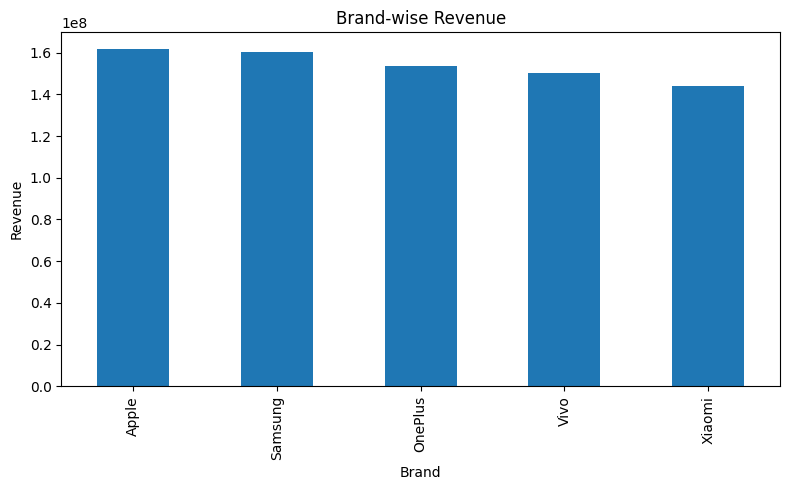

In [16]:
# Brand Revenue Chart
plt.figure(figsize=(8,5))
brand_sales.plot(kind='bar')
plt.title("Brand-wise Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

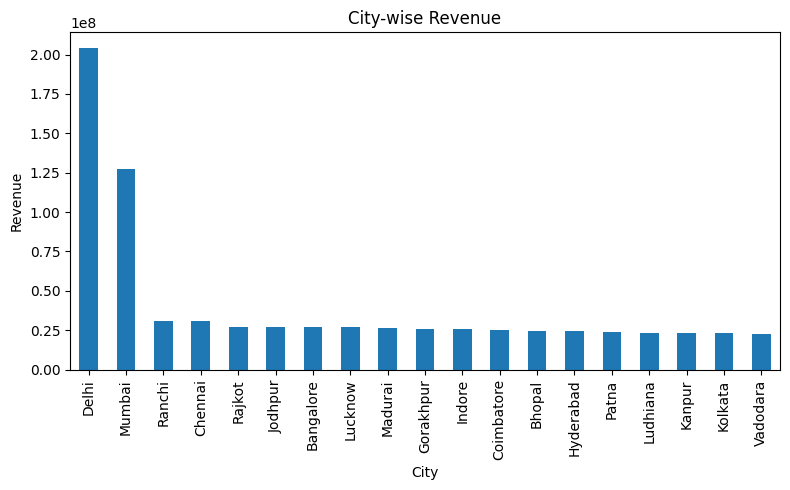

In [17]:
# City Revenue Chart
plt.figure(figsize=(8,5))
city_sales.plot(kind='bar')
plt.title("City-wise Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

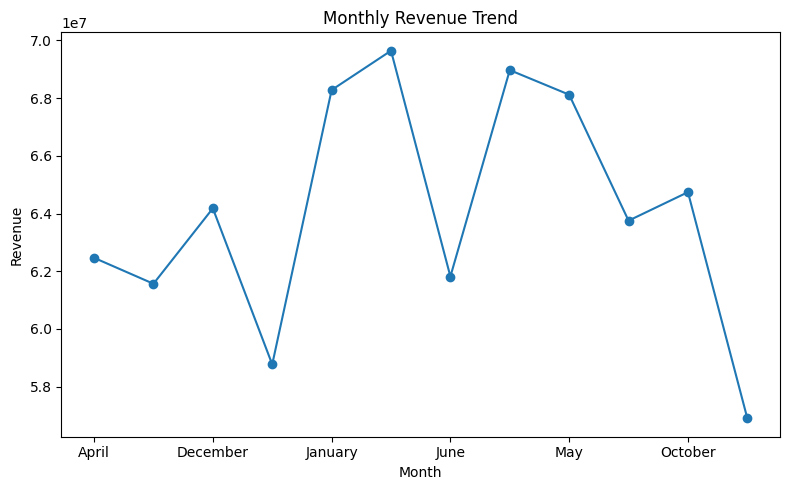

In [18]:
# Monthly Sales Trend
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Export Cleaned Data

In [20]:
df.to_csv(r"C:\Users\hp\OneDrive\Desktop\Capstone Project\CP1\cleaned_mobile_sales_data.csv", index=False)